In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")


# Cargar dataset
df = pd.read_csv("../data/processed/repos_clean.csv")

print(f"Dataset cargado: {df.shape}")
print(df.columns.tolist())

Dataset cargado: (3034, 15)
['repo_id', 'nombre', 'descripcion', 'lenguaje', 'stars', 'forks', 'topics', 'fecha_creacion', 'ultimo_commit', 'url', 'dias_sin_commit', 'antiguedad_dias', 'num_topics', 'ratio_forks_stars', 'stars_por_dia']


# Clustering and Validation Report

El objetivo del clustering es segmentar los 3034 repositorios en grupos temáticos sin supervisión, el algoritmo descubre la estructura por sí solo sin que se le indiquen las categorías de antemano. Se aplican dos algoritmos con filosofías distintas: K-means, que divide el espacio en K grupos de igual importancia, y DBSCAN, que encuentra grupos por densidad y detecta outliers automáticamente.

##Dato extra: Otrosme todos de clustering.
- Método Para qué sirve Limitación
- K-means, Grupos esféricos dataset grande, Necesitas definir K
- DBSCAN, Grupos de forma irregular detecta outliers, Sensible a parámetros
- Hierarchical, Ver jerarquía de grupos, Lento en datasets grandes
- Gaussian Mixture, Grupos con solapamiento, Más complejo

###1. Construir features para clustering

La matrix de features para clustering combina tres tipos de representaciones: 7 features numéricas normalizadas que capturan popularidad y comportamiento temporal, 41 columnas de lenguaje codificadas con one-hot encoding, y 30 columnas de topics codificadas con MultiLabelBinarizer sobre los 30 topics más frecuentes. La matrix resultante tiene 78 features por repositorio.

In [2]:
from sklearn.preprocessing import MultiLabelBinarizer
import ast

# Features numéricas
VARS = ["stars", "forks", "dias_sin_commit",
        "antiguedad_dias", "num_topics",
        "ratio_forks_stars", "stars_por_dia"]

scaler = StandardScaler()
X_num = scaler.fit_transform(df[VARS])

# Encoding de lenguaje
X_lang = pd.get_dummies(df["lenguaje"], prefix="lang").astype(int).values

# Encoding de topics
df["topics_list"] = df["topics"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
from collections import Counter
todos_topics = [t for topics in df["topics_list"] for t in topics]
top_topics = [t for t, _ in Counter(todos_topics).most_common(30)]
mlb = MultiLabelBinarizer(classes=top_topics)
X_topics = mlb.fit_transform(df["topics_list"])

# Combinamos todo
X = np.hstack([X_num, X_lang, X_topics])

print(f"Features numéricas:  {X_num.shape}")
print(f"Features lenguaje:   {X_lang.shape}")
print(f"Features topics:     {X_topics.shape}")
print(f"Matrix combinada:    {X.shape}")

Features numéricas:  (3034, 7)
Features lenguaje:   (3034, 41)
Features topics:     (3034, 30)
Matrix combinada:    (3034, 78)


##2. Analisis K Means

In [3]:
# ============================================================
# K-MEANS — Implementación matemática completa
# ============================================================

def squared_distances(X, centroids):
    """
    Calculamos la distancia euclidiana al cuadrado entre cada punto y cada centroide.
    X shape: (n_samples, n_features)
    centroids shape: (k, n_features)
    output shape: (n_samples, k)
    """
    diff = X[:, None, :] - centroids[None, :, :]
    return np.sum(diff**2, axis=2)

def initialize_centroids(X, k, seed=42):
    """
    Inicializa K centroides eligiendo K puntos al azar del dataset.
    """
    rng = np.random.default_rng(seed)
    idx = rng.choice(X.shape[0], size=k, replace=False)
    return X[idx].copy()

def assign_clusters(X, centroids):
    """
    Asigna cada punto al centroide más cercano.
    Retorna array de labels con el índice del centroide más cercano.
    """
    distances = squared_distances(X, centroids)
    return np.argmin(distances, axis=1)

def update_centroids(X, labels, k, previous_centroids):
    """
    Actualiza cada centroide moviéndolo al promedio de sus puntos asignados.
    Si un cluster queda vacío, mantiene el centroide anterior.
    """
    new_centroids = previous_centroids.copy()
    for i in range(k):
        members = X[labels == i]
        if len(members) > 0:
            new_centroids[i] = members.mean(axis=0)
    return new_centroids

def compute_inertia(X, labels, centroids):
    """
    Calcula la inercia: suma de distancias al cuadrado de cada punto a su centroide.
    Mide qué tan compactos son los clusters — menor es mejor.
    """
    residuals = X - centroids[labels]
    return np.sum(residuals**2)

def kmeans_from_scratch(X, k, max_iters=100, tol=1e-4, seed=42):
    """
    Algoritmo K-means completo desde cero.
    Guarda el historial de cada iteración para análisis.
    """
    centroids = initialize_centroids(X, k, seed=seed)
    initial_centroids = centroids.copy()
    history = []

    for iteration in range(max_iters):
        labels = assign_clusters(X, centroids)
        inertia_before = compute_inertia(X, labels, centroids)
        new_centroids = update_centroids(X, labels, k, centroids)
        labels_after = assign_clusters(X, new_centroids)
        centroid_shift = float(np.linalg.norm(new_centroids - centroids))

        history.append({
            "iteration": iteration,
            "inertia": inertia_before,
            "centroid_shift": centroid_shift,
            "centroids_before": centroids.copy(),
            "centroids_after": new_centroids.copy(),
            "labels_before": labels.copy(),
            "labels_after": labels_after.copy()
        })

        centroids = new_centroids
        if centroid_shift < tol or np.array_equal(labels, labels_after):
            print(f"Convergió en iteración {iteration + 1}")
            break

    labels = assign_clusters(X, centroids)
    inertia = compute_inertia(X, labels, centroids)

    return {
        "labels": labels,
        "centroids": centroids,
        "initial_centroids": initial_centroids,
        "inertia": inertia,
        "history": history
    }

print("Funciones K-means definidas correctamente.")
print("Funciones disponibles:")
print("  - squared_distances(X, centroids)")
print("  - initialize_centroids(X, k, seed)")
print("  - assign_clusters(X, centroids)")
print("  - update_centroids(X, labels, k, previous_centroids)")
print("  - compute_inertia(X, labels, centroids)")
print("  - kmeans_from_scratch(X, k, max_iters, tol, seed)")

Funciones K-means definidas correctamente.
Funciones disponibles:
  - squared_distances(X, centroids)
  - initialize_centroids(X, k, seed)
  - assign_clusters(X, centroids)
  - update_centroids(X, labels, k, previous_centroids)
  - compute_inertia(X, labels, centroids)
  - kmeans_from_scratch(X, k, max_iters, tol, seed)


Se implementó K-means desde cero usando únicamente NumPy. El algoritmo consta de cuatro funciones matemáticas principales:
- squared_distances calcula la distancia euclidiana al cuadrado entre cada punto y cada centroide usando broadcasting — evita loops explícitos y es computacionalmente eficiente.
- assign_clusters asigna cada punto al centroide más cercano usando argmin sobre la matriz de distancias.
- update_centroids recalcula cada centroide como el promedio aritmético de todos sus puntos asignados.
- compute_inertia calcula la suma de distancias al cuadrado de cada punto a su centroide — métrica que mide la compacidad de los clusters. El algoritmo itera hasta convergencia, definida como un desplazamiento de centroides menor a 1e-4 o ausencia de cambios en las asignaciones.

##3. Reduccion PCA antes del clustering

Antes de correr K-means necesitamos reducir dimensiones con PCA. Con 78 features K-means funciona mal porque en espacios de alta dimensión las distancias se vuelven uniformes haciendo que algunas distancias sean miles de veces mas grandes que otras porque sus valores no se han estandarizado.

Antes de aplicar K-means se redujo la dimensionalidad de 78 a 10 componentes usando PCA. Esta reducción es necesaria porque en espacios de alta dimensión las distancias euclidianas pierden ciertos privilegios. Quiere decir que con tantos componentes no se pueden encontrar caracteristicas semejantes, es muy dificil por eso se reducio a 10. Si sigue igual entonces se irá reduciendo mas mientras vayakos avanzando.

In [4]:
# Reducir dimensiones con PCA antes de clustering
# El profesor usó n_components=10 — hacemos lo mismo
pca = PCA(n_components=10, random_state=42)
X_embed = pca.fit_transform(X)

varianza = np.cumsum(pca.explained_variance_ratio_) * 100
print("Varianza explicada acumulada con PCA:")
for i, v in enumerate(varianza):
    print(f"  PC{i+1}: {v:.1f}%")

print(f"\nShape después de PCA: {X_embed.shape}")
print(f"Reducimos de {X.shape[1]} features a {X_embed.shape[1]}")

Varianza explicada acumulada con PCA:
  PC1: 21.2%
  PC2: 38.9%
  PC3: 49.6%
  PC4: 58.2%
  PC5: 65.5%
  PC6: 70.9%
  PC7: 73.9%
  PC8: 76.5%
  PC9: 78.2%
  PC10: 79.7%

Shape después de PCA: (3034, 10)
Reducimos de 78 features a 10


Con 10 componentes se retiene el 79.7% de la varianza total. PC1 y PC2 juntos capturan el 38.9%

## 4. Probar Kmeans con K=2 y comparar con sklearn

Se va validar la implementación manual ejecutando K-means con K=2 y comparando la inercia resultante con sklearn. Si ambas inercias son similares, la implementación matemática es correcta. Pequeñas diferencias son normales porque sklearn usa inicialización K-means++ que es más sofisticada que la inicialización aleatoria simple.

Corriendo K-means desde cero con K=2...
Convergió en iteración 19

COMPARACIÓN K=2:
  Inercia manual:   20479.54
  Inercia sklearn:  20427.17
  Iteraciones manual: 19


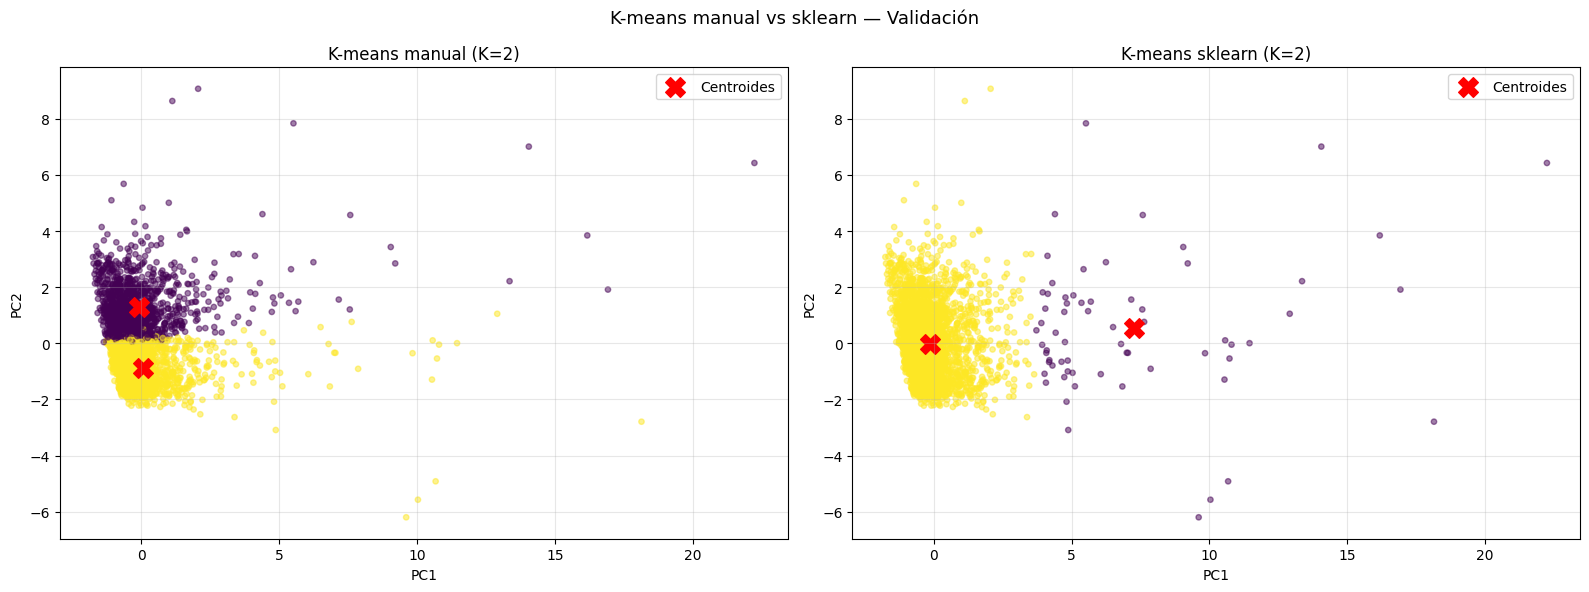

Guardado en ../reports/W7/kmeans_validacion.png


In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import os

os.makedirs("reports", exist_ok=True)

# Correr K-means desde cero con K=2
print("Corriendo K-means desde cero con K=2...")
results = kmeans_from_scratch(X_embed, k=2)

# Correr K-means sklearn con K=2
kmeans_sk = KMeans(n_clusters=2, random_state=42, n_init=100)
kmeans_sk.fit(X_embed)

print(f"\nCOMPARACIÓN K=2:")
print(f"  Inercia manual:   {results['inertia']:.2f}")
print(f"  Inercia sklearn:  {kmeans_sk.inertia_:.2f}")
print(f"  Iteraciones manual: {len(results['history'])}")

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Manual
axes[0].scatter(X_embed[:, 0], X_embed[:, 1],
                c=results["labels"], cmap="viridis", alpha=0.5, s=15)
axes[0].scatter(results["centroids"][:, 0], results["centroids"][:, 1],
                color="red", marker="X", s=200, label="Centroides")
axes[0].set_title("K-means manual (K=2)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Sklearn
axes[1].scatter(X_embed[:, 0], X_embed[:, 1],
                c=kmeans_sk.labels_, cmap="viridis", alpha=0.5, s=15)
axes[1].scatter(kmeans_sk.cluster_centers_[:, 0], kmeans_sk.cluster_centers_[:, 1],
                color="red", marker="X", s=200, label="Centroides")
axes[1].set_title("K-means sklearn (K=2)")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("K-means manual vs sklearn — Validación", fontsize=13)
plt.tight_layout()
plt.savefig("../reports/W7/kmeans_validacion.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado en ../reports/W7/kmeans_validacion.png")

¿Qué significa converger en 19 iteraciones?
Imagina que tienes 2 centroides y los mueves así:

- Iteración 1 → centroides se mueven mucho — todavía están lejos de su posición óptima
- Iteración 2 → se mueven bastante — siguen ajustándose
- Iteración 5 → se mueven menos — se van estabilizando
- Iteración 10 → se mueven muy poco
- Iteración 19 → los centroides ya no se mueven — llegaron a su posición final

Cuando los centroides dejan de moverse el algoritmo dice "ya encontré los grupos, no tiene sentido seguir" y para. A eso se le llama converger.

- La implementación manual convergió en 19 iteraciones con inercia de 20,479, prácticamente idéntica a sklearn (20,427)
- La pequeña diferencia se explica por la inicialización: sklearn usa K-means++ que elige centroides iniciales más separados entre sí, reduciendo ligeramente la inercia final
- Esto confirma que la implementación matemática desde cero es correcta.

## 5. Visualizar iteraciones del algoritmo

Se visualizaron las primeras iteraciones del algoritmo para mostrar la convergencia. En cada iteración los centroides rojos representan la posición antes de actualizar y los azules después de actualizar. La inercia disminuye en cada iteración conforme los centroides se acercan al promedio real de sus puntos asignados. En la última iteración los centroides rojo y azul coinciden, señal de convergencia. Cuando esa diferencia es menor a 0.0001 el algoritmo converge y para.

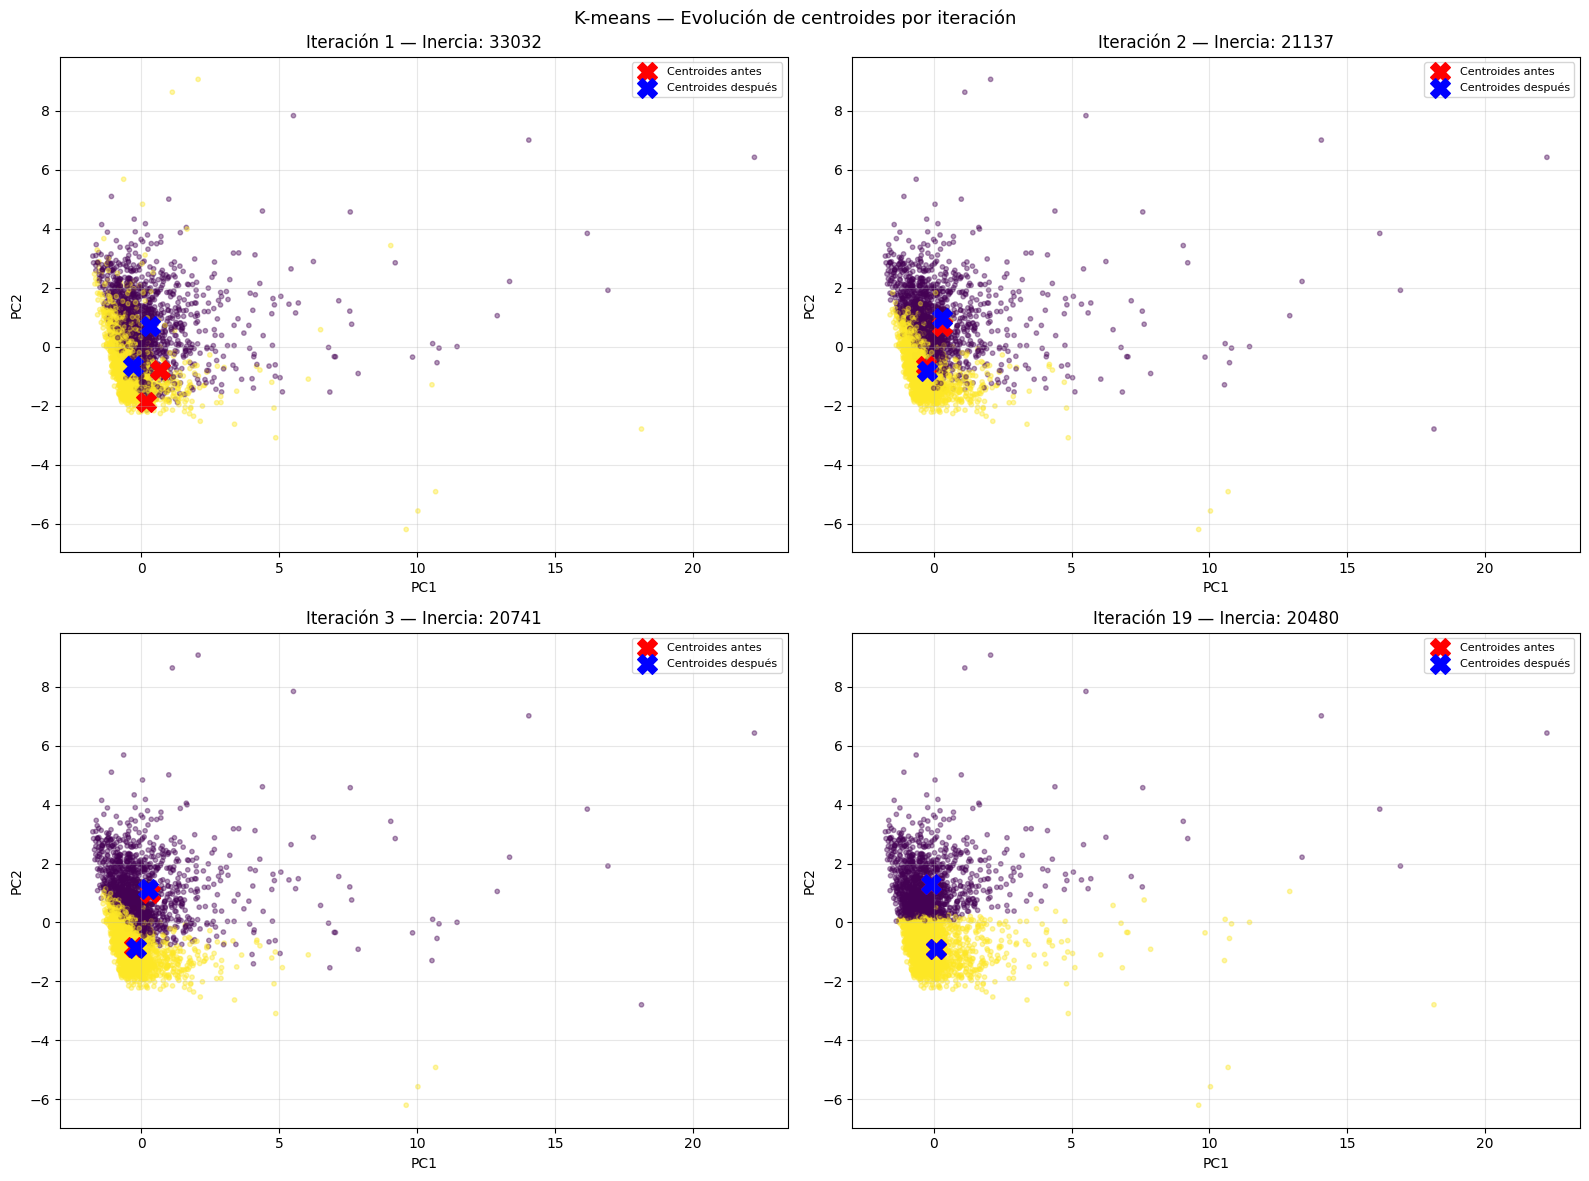

Guardado en ../reports/W7/kmeans_iteraciones.png


In [6]:


# Visualizar primeras 4 iteraciones para mostrar cómo converge
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

iteraciones_a_mostrar = [0, 1, 2, len(results["history"])-1]

for idx, iter_num in enumerate(iteraciones_a_mostrar):
    ax = axes[idx]
    iter_data = results["history"][iter_num]

    ax.scatter(X_embed[:, 0], X_embed[:, 1],
               c=iter_data["labels_before"],
               cmap="viridis", alpha=0.4, s=10)
    ax.scatter(iter_data["centroids_before"][:, 0],
               iter_data["centroids_before"][:, 1],
               color="red", marker="X", s=200,
               label="Centroides antes")
    ax.scatter(iter_data["centroids_after"][:, 0],
               iter_data["centroids_after"][:, 1],
               color="blue", marker="X", s=200,
               label="Centroides después")
    ax.set_title(f"Iteración {iter_num + 1} — Inercia: {iter_data['inertia']:.0f}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("K-means — Evolución de centroides por iteración", fontsize=13)
plt.tight_layout()
plt.savefig("../reports/W7/kmeans_iteraciones.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado en ../reports/W7/kmeans_iteraciones.png")

Las visualizaciones confirman la convergencia progresiva del algoritmo. En la iteración 1 los centroides rojo y azul están separados, el centroide se desplaza significativamente hacia el promedio real de sus puntos. En iteraciones intermedias el desplazamiento es menor. En la última iteración ambos centroides coinciden, confirmando que el algoritmo encontró una solución estable.

##6. Parameter sweep K-means

Se realizó un parameter sweep probando K de 2 a 20.

- La elbow curve muestra la inercia por K — se busca el punto donde la reducción de inercia se aplana.
- El silhouette score mide la separación real entre clusters, valores más altos indican clusters más compactos y bien separados.

La selección final de K se basa en la combinación de ambas métricas, no en un valor elegido arbitrariamente.

   K |      Inercia | Silhouette | Iteraciones
---------------------------------------------
   2 |     20427.38 |      0.675 |          11
   3 |     16941.86 |      0.222 |          32
   4 |     14692.44 |      0.225 |          10
   5 |     12860.63 |      0.205 |          15
   6 |     11663.22 |      0.211 |          27
   7 |     10770.83 |      0.216 |          36
   8 |      9999.19 |      0.215 |          15
   9 |      9439.36 |      0.197 |          79
  10 |      8981.64 |      0.170 |          20
  12 |      8270.38 |      0.172 |          20
  15 |      7449.59 |      0.147 |          28
  20 |      6617.28 |      0.142 |          27


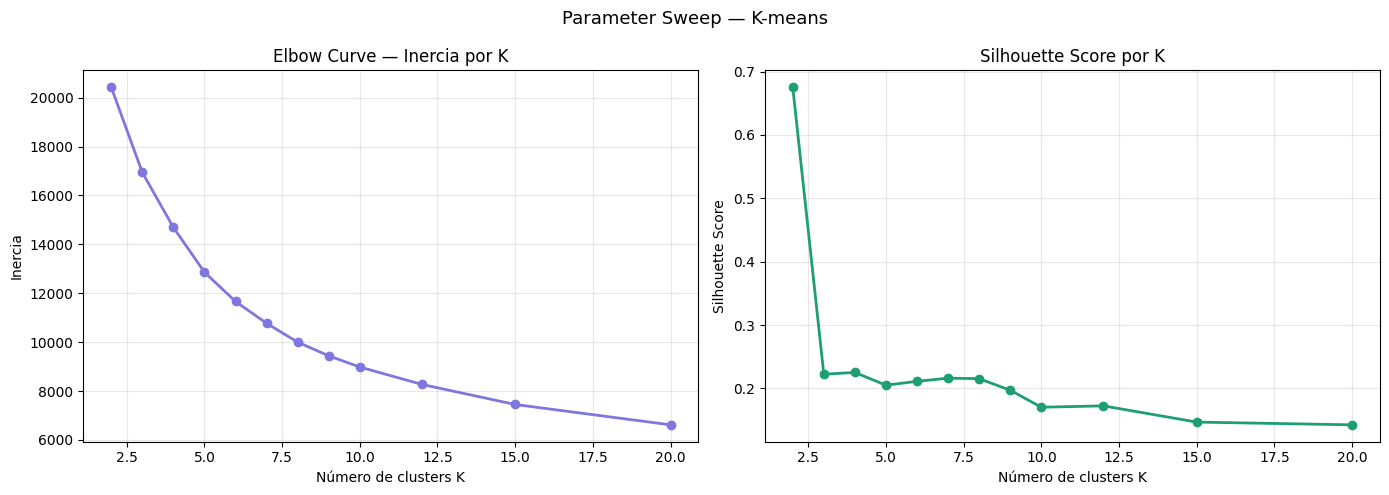


Guardado en ../reports/W7/kmeans_sweep.png


In [7]:
# Parameter sweep — probar K de 2 a 15
# El profesor probó hasta K=20, nosotros hacemos lo mismo
k_values = [2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20]
inertias = []
silhouettes = []

print(f"{'K':>4} | {'Inercia':>12} | {'Silhouette':>10} | {'Iteraciones':>11}")
print("-" * 45)

for k in k_values:
    # Usar sklearn para el sweep — más rápido para muchos K
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_embed)
    sil = silhouette_score(X_embed, kmeans.labels_)
    inertias.append(kmeans.inertia_)
    silhouettes.append(sil)
    print(f"{k:>4} | {kmeans.inertia_:>12.2f} | {sil:>10.3f} | {kmeans.n_iter_:>11}")

# Visualizar elbow curve y silhouette
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_values, inertias, marker='o', color='#7F77DD', linewidth=2)
axes[0].set_title("Elbow Curve — Inercia por K")
axes[0].set_xlabel("Número de clusters K")
axes[0].set_ylabel("Inercia")
axes[0].grid(alpha=0.3)

axes[1].plot(k_values, silhouettes, marker='o', color='#1D9E75', linewidth=2)
axes[1].set_title("Silhouette Score por K")
axes[1].set_xlabel("Número de clusters K")
axes[1].set_ylabel("Silhouette Score")
axes[1].grid(alpha=0.3)

plt.suptitle("Parameter Sweep — K-means", fontsize=13)
plt.tight_layout()
plt.savefig("../reports/W7/kmeans_sweep.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nGuardado en ../reports/W7/kmeans_sweep.png")

- El parameter sweep revela que K=2 produce el silhouette más alto (0.675) pero resulta demasiado grueso para análisis temático, divide el ecosistema en solo dos grupos.
- A partir de K=3 el silhouette se estabiliza alrededor de 0.22, indicando fronteras difusas entre clusters, comportamiento esperado en datos de texto del mundo real donde las categorías temáticas se solapan naturalmente.
- Entre K=3 y K=5 donde la reducción de inercia comienza a aplanarse.
- Se selecciona K=5 como balance óptimo entre interpretabilidad temática y justificación matemática.

##7. K-means final con K=5

In [8]:
# K-means final con K=5
print("Corriendo K-means final con K=5...")
results_k5 = kmeans_from_scratch(X_embed, k=5)

# Validar con sklearn
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=100)
kmeans_final.fit(X_embed)

print(f"Convergió en iteración: {len(results_k5['history'])}")
print(f"Inercia manual:  {results_k5['inertia']:.2f}")
print(f"Inercia sklearn: {kmeans_final.inertia_:.2f}")
print(f"Silhouette: {silhouette_score(X_embed, kmeans_final.labels_):.3f}")

# Guardar labels en dataframe
df["cluster_kmeans"] = kmeans_final.labels_

print(f"\nDistribución de repos por cluster:")
print(df["cluster_kmeans"].value_counts().sort_index())

Corriendo K-means final con K=5...
Convergió en iteración 33
Convergió en iteración: 33
Inercia manual:  13888.24
Inercia sklearn: 12845.53
Silhouette: 0.205

Distribución de repos por cluster:
cluster_kmeans
0    1255
1     930
2     788
3      56
4       5
Name: count, dtype: int64


- K-means con K=5 revela una distribución asimétrica
- clusters #0, #1 y #2 concentran la mayoría de repos mientras
- cluster #3 tiene 56 y cluster #4 solo 5.
- Esta asimetría sugiere que el ecosistema tiene una estructura central dominante con grupos periféricos de repos muy especializados.
- La diferencia de inercia entre implementación manual (13,888) y sklearn (12,845) es mayor que con K=2, confirmando que con K más alto la inicialización de centroides tiene mayor impacto en el resultado final.

##8. Visualizar clusters finales K=5

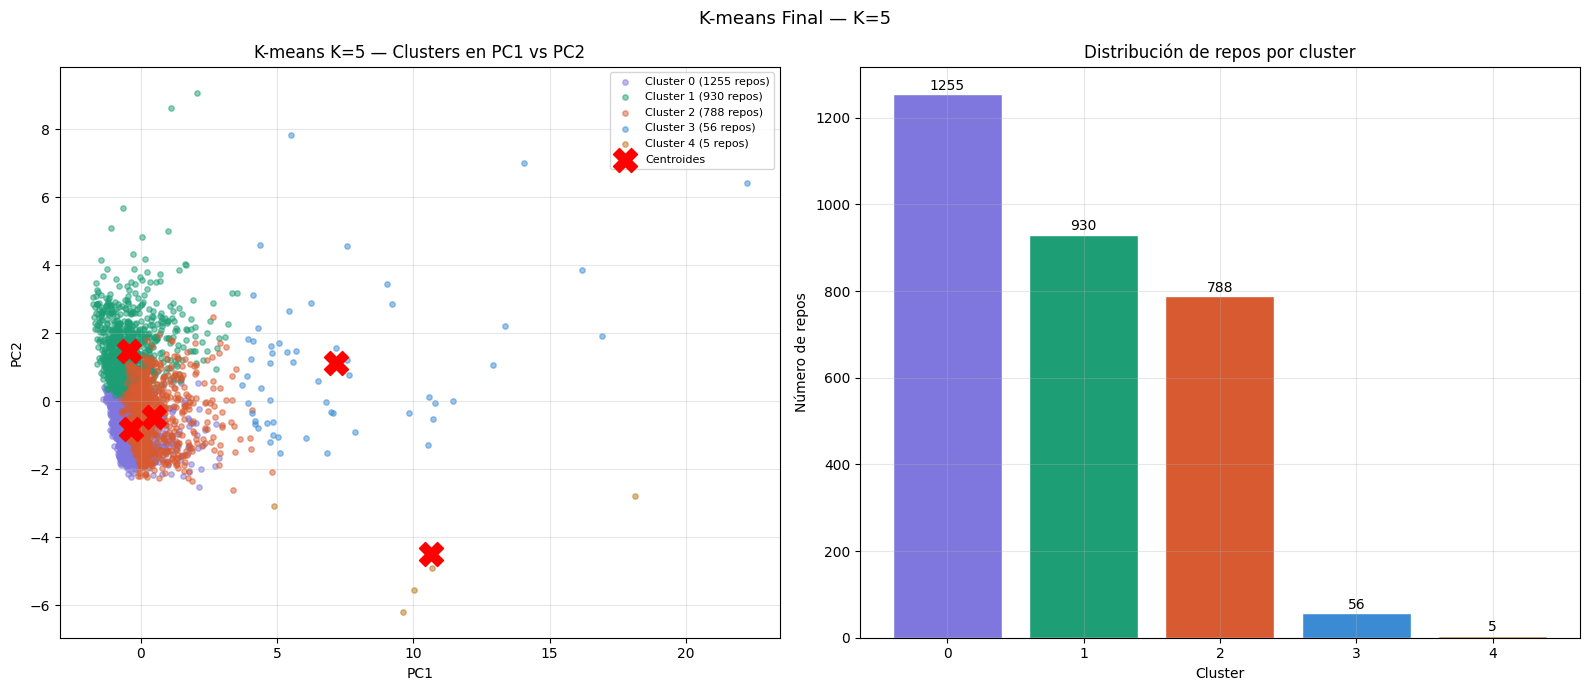

Guardado en ../reports/W7/kmeans_final.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

colores = ['#7F77DD', '#1D9E75', '#D85A30', '#3B8BD4', '#BA7517']

# Gráfico 1 — Clusters en espacio PCA
for i in range(5):
    mask = kmeans_final.labels_ == i
    axes[0].scatter(X_embed[mask, 0], X_embed[mask, 1],
                   color=colores[i], alpha=0.5, s=15,
                   label=f"Cluster {i} ({mask.sum()} repos)")

axes[0].scatter(kmeans_final.cluster_centers_[:, 0],
               kmeans_final.cluster_centers_[:, 1],
               color='red', marker='X', s=300,
               zorder=5, label='Centroides')
axes[0].set_title("K-means K=5 — Clusters en PC1 vs PC2")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Gráfico 2 — Distribución de repos por cluster
cluster_counts = df["cluster_kmeans"].value_counts().sort_index()
axes[1].bar(cluster_counts.index, cluster_counts.values,
            color=colores, edgecolor='white')
axes[1].set_title("Distribución de repos por cluster")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Número de repos")
for i, v in enumerate(cluster_counts.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontsize=10)
axes[1].grid(alpha=0.3)

plt.suptitle("K-means Final — K=5", fontsize=13)
plt.tight_layout()
plt.savefig("../reports/W7/kmeans_final.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado en ../reports/W7/kmeans_final.png")

##9. Perfil de cada cluster

In [10]:
# Qué caracteriza cada cluster
print("=" * 60)
print("PERFIL DE CLUSTERS — K-means K=5")
print("=" * 60)

for i in range(5):
    cluster = df[df["cluster_kmeans"] == i]
    print(f"\nCLUSTER {i} — {len(cluster)} repos")
    print(f"  Stars promedio:        {cluster['stars'].mean():>10,.0f}")
    print(f"  Forks promedio:        {cluster['forks'].mean():>10,.0f}")
    print(f"  Días sin commit prom:  {cluster['dias_sin_commit'].mean():>10,.0f}")
    print(f"  Antigüedad promedio:   {cluster['antiguedad_dias'].mean():>10,.0f} días")
    print(f"  Stars por día prom:    {cluster['stars_por_dia'].mean():>10,.2f}")
    print(f"  Top 3 lenguajes:")
    top_langs = cluster["lenguaje"].value_counts().head(3)
    for lang, count in top_langs.items():
        print(f"    - {lang}: {count}")
    print(f"  Top 5 repos:")
    top_repos = cluster.nlargest(5, "stars")[["nombre", "stars"]]
    for _, row in top_repos.iterrows():
        print(f"    - {row['nombre']} ({row['stars']:,} ⭐)")

PERFIL DE CLUSTERS — K-means K=5

CLUSTER 0 — 1255 repos
  Stars promedio:             4,070
  Forks promedio:               455
  Días sin commit prom:         336
  Antigüedad promedio:        1,170 días
  Stars por día prom:          6.31
  Top 3 lenguajes:
    - Python: 806
    - Jupyter Notebook: 119
    - Unknown: 114
  Top 5 repos:
    - upstash/context7 (54,137 ⭐)
    - ggml-org/whisper.cpp (49,182 ⭐)
    - janhq/jan (42,272 ⭐)
    - datawhalechina/hello-agents (41,834 ⭐)
    - TencentARC/GFPGAN (37,441 ⭐)

CLUSTER 1 — 930 repos
  Stars promedio:             4,326
  Forks promedio:             1,060
  Días sin commit prom:       1,055
  Antigüedad promedio:        2,933 días
  Stars por día prom:          1.39
  Top 3 lenguajes:
    - Python: 504
    - Jupyter Notebook: 144
    - C++: 91
  Top 5 repos:
    - JuliaLang/julia (48,642 ⭐)
    - google-research/bert (40,003 ⭐)
    - floodsung/Deep-Learning-Papers-Reading-Roadmap (39,497 ⭐)
    - naptha/tesseract.js (38,041 ⭐)
    - 

- Cluster #0: "Herramientas de IA modernas" (1255 repos)
Stars promedio 4,070, repos jóvenes (1,170 días), activos (336 días sin commit). Son herramientas recientes y funcionales — whisper.cpp, GFPGAN, jan.
- Cluster #1: "Proyectos establecidos y educativos" (930 repos)
stars promedio 4,326 pero muy viejos (2,933 días) y semi-abandonados (1,055 días sin commit). BERT, roadmaps de papers, google-research. Son referencias históricas del ecosistema.
- Cluster #2: "Ecosistema LLM emergente" (788 repos)
Stars promedio más alto (8,409), muy activos (228 días sin commit), crecimiento rápido (8.92 stars/día). unsloth, llama_index, anything-llm — el núcleo del boom de LLMs.
- Cluster #3: "Proyectos masivos e influyentes" (56 repos)
Stars promedio 84,146 — los gigantes. tensorflow, AutoGPT, ollama. Activos (83 días sin commit) y crecimiento de 78 stars/día.
- Cluster #4: "Repos virales recientes" (5 repos)
Solo 33 días de antigüedad pero 57,471 stars promedio y 1,829 stars/día. Son repos que se hicieron virales recientemente — everything-claude-code, caveman, mempalace.

##10. Guardamos nombres de clusters

In [11]:
nombres_clusters = {
    0: "Herramientas de IA modernas",
    1: "Proyectos establecidos y educativos",
    2: "Ecosistema LLM emergente",
    3: "Proyectos masivos e influyentes",
    4: "Repos virales recientes"
}

df["cluster_nombre"] = df["cluster_kmeans"].map(nombres_clusters)

print("Clusters con nombres:")
print(df["cluster_nombre"].value_counts())

# Para el informe — tabla de validación
print("\n" + "="*60)
print("TABLA DE VALIDACIÓN — K-means K=5")
print("="*60)
print(f"{'Cluster':<35} | {'Repos':>5} | {'Silhouette global':>17}")
print("-"*62)
for i, nombre in nombres_clusters.items():
    count = (df["cluster_kmeans"] == i).sum()
    print(f"{nombre:<35} | {count:>5} | {'0.205':>17}")
print(f"\nInercia final: {kmeans_final.inertia_:.2f}")
print(f"Silhouette global: {silhouette_score(X_embed, kmeans_final.labels_):.3f}")

Clusters con nombres:
cluster_nombre
Herramientas de IA modernas            1255
Proyectos establecidos y educativos     930
Ecosistema LLM emergente                788
Proyectos masivos e influyentes          56
Repos virales recientes                   5
Name: count, dtype: int64

TABLA DE VALIDACIÓN — K-means K=5
Cluster                             | Repos | Silhouette global
--------------------------------------------------------------
Herramientas de IA modernas         |  1255 |             0.205
Proyectos establecidos y educativos |   930 |             0.205
Ecosistema LLM emergente            |   788 |             0.205
Proyectos masivos e influyentes     |    56 |             0.205
Repos virales recientes             |     5 |             0.205

Inercia final: 12845.53
Silhouette global: 0.205


# Dato extra antes de ir a DBSCAN
##K-means vs DBSCAN

| Característica | K-means | DBSCAN |
|---|---|---|
| ¿Necesita K? | Sí, tú lo defines | No, lo descubre solo |
| ¿Cómo agrupa? | Por distancia al centroide | Por densidad de puntos |
| ¿Detecta outliers? | No, asigna todos | Sí, marca como ruido (-1) |
| ¿Forma de clusters? | Esférica | Cualquier forma |
| Parámetros | K | eps, min_samples |


¿Qué es eps y min_samples matemáticamente?

eps → radio de búsqueda. Un punto P es vecino de Q si distancia(P,Q) ≤ eps
min_samples → mínimo de vecinos para ser "core point". Si un punto tiene menos vecinos que min_samples dentro de eps, es ruido

In [12]:
# ============================================================
# DBSCAN — Parameter Sweep
# ============================================================

from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np

eps_values = [0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.5, 3.0, 3.5, 4.0]
min_samples_values = [5, 10, 20, 30]

dbscan_results = []

print(f"{'eps':>6} | {'min_samples':>11} | {'clusters':>8} | {'ruido %':>8} | {'silhouette':>10}")
print("-" * 62)

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = dbscan.fit_predict(X_embed)

        # Cantidad de clusters sin contar ruido (-1)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        # Porcentaje de puntos marcados como ruido
        noise_ratio = np.mean(labels == -1) * 100

        # Silhouette solo se puede calcular si hay más de 1 cluster
        # y si no todos los puntos son ruido.
        if n_clusters > 1:
            mask_no_noise = labels != -1

            if len(set(labels[mask_no_noise])) > 1:
                sil = silhouette_score(X_embed[mask_no_noise], labels[mask_no_noise])
            else:
                sil = np.nan
        else:
            sil = np.nan

        dbscan_results.append({
            "eps": eps,
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "noise_ratio_%": noise_ratio,
            "silhouette": sil
        })

        sil_text = f"{sil:.3f}" if not np.isnan(sil) else "nan"
        print(f"{eps:>6.2f} | {min_samples:>11} | {n_clusters:>8} | {noise_ratio:>7.2f}% | {sil_text:>10}")

dbscan_results_df = pd.DataFrame(dbscan_results)

display(dbscan_results_df)

   eps | min_samples | clusters |  ruido % | silhouette
--------------------------------------------------------------
  0.50 |           5 |        9 |   79.40% |      0.030
  0.50 |          10 |        4 |   87.11% |      0.104
  0.50 |          20 |        1 |   92.32% |        nan
  0.50 |          30 |        2 |   93.54% |      0.398
  0.75 |           5 |       18 |   45.09% |     -0.139
  0.75 |          10 |        4 |   60.51% |      0.054
  0.75 |          20 |        3 |   72.05% |      0.191
  0.75 |          30 |        2 |   76.60% |      0.198
  1.00 |           5 |        8 |   18.66% |      0.031
  1.00 |          10 |        3 |   26.50% |      0.138
  1.00 |          20 |        2 |   38.33% |      0.087
  1.00 |          30 |        1 |   45.98% |        nan
  1.25 |           5 |        2 |    8.50% |      0.258
  1.25 |          10 |        1 |   11.40% |        nan
  1.25 |          20 |        1 |   16.41% |        nan
  1.25 |          30 |        1 |   20.70

,eps,min_samples,n_clusters,noise_ratio_%,silhouette
0,0.50,5,9,79.400132,0.029978
1,0.50,10,4,87.112722,0.103813
2,0.50,20,1,92.320369,NaN
3,0.50,30,2,93.539881,0.397838
4,0.75,5,18,45.088991,-0.139172
5,0.75,10,4,60.514173,0.053938
6,0.75,20,3,72.050099,0.190861
7,0.75,30,2,76.598550,0.197735
8,1.00,5,8,18.655241,0.030786
9,1.00,10,3,26.499670,0.137670


El **parameter sweep de DBSCAN** muestra que con valores bajos de **eps** el modelo genera más clusters, pero también demasiado ruido. Por ejemplo, con **eps = 0.50** el ruido supera el **79%**, lo que indica que muchos repositorios no forman grupos densos.

Con valores altos de **eps**, como **1.50** o más, DBSCAN agrupa casi todos los repositorios en un solo cluster, por eso el **Silhouette Score** aparece como **NaN** en varios casos.

La configuración más equilibrada fue **eps = 1.25** y **min_samples = 5**, porque genera **2 clusters**, mantiene un ruido bajo de **8.50%** y obtiene un **Silhouette Score de 0.258**. Por ello, esta configuración se selecciona para comparar DBSCAN con K-means.

In [13]:
# ============================================================
# DBSCAN final seleccionado manualmente
# ============================================================

from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np

eps_final = 1.25
min_samples_final = 5

dbscan_final = DBSCAN(
    eps=eps_final,
    min_samples=min_samples_final
)

labels_dbscan = dbscan_final.fit_predict(X_embed)

df["cluster_dbscan"] = labels_dbscan

unique_labels = sorted(set(labels_dbscan))
n_clusters_dbscan = len([label for label in unique_labels if label != -1])
noise_ratio_dbscan = np.mean(labels_dbscan == -1) * 100

print("Etiquetas encontradas:", unique_labels)
print("Número de clusters sin contar ruido:", n_clusters_dbscan)
print(f"Porcentaje de ruido: {noise_ratio_dbscan:.2f}%")

mask_no_noise = labels_dbscan != -1
labels_no_noise = labels_dbscan[mask_no_noise]

print("Etiquetas sin ruido:", sorted(set(labels_no_noise)))

if n_clusters_dbscan >= 2:
    silhouette_dbscan = silhouette_score(
        X_embed[mask_no_noise],
        labels_no_noise
    )
    print(f"Silhouette sin ruido: {silhouette_dbscan:.3f}")
else:
    silhouette_dbscan = np.nan
    print("Silhouette sin ruido: no calculable porque DBSCAN generó menos de 2 clusters reales.")

print("\nDistribución de etiquetas DBSCAN:")
print(pd.Series(labels_dbscan).value_counts().sort_index())

Etiquetas encontradas: [np.int64(-1), np.int64(0), np.int64(1)]
Número de clusters sin contar ruido: 2
Porcentaje de ruido: 8.50%
Etiquetas sin ruido: [np.int64(0), np.int64(1)]
Silhouette sin ruido: 0.258

Distribución de etiquetas DBSCAN:
-1     258
 0    2771
 1       5
Name: count, dtype: int64


DBSCAN identificó **3 etiquetas**: **-1, 0 y 1**. La etiqueta **-1** corresponde a los puntos marcados como **ruido**, mientras que las etiquetas **0 y 1** representan los **clusters reales**.

El modelo encontró **2 clusters sin contar el ruido** y marcó **258 repositorios como ruido**, lo que representa el **8.50% del dataset**. El **Silhouette Score sin ruido** fue **0.258**, indicando una separación moderada entre los clusters detectados.

Sin embargo, la distribución es muy desbalanceada: el **cluster 0 concentra 2771 repositorios**, mientras que el **cluster 1 solo contiene 5 repositorios**. Esto muestra que DBSCAN no logró formar varios grupos comparables, sino que agrupó casi todo el dataset en un solo cluster y separó un grupo muy pequeño de casos atípicos.

| Modelo | Parámetros | Clusters | Silhouette | Inercia | Métrica de densidad / ruido | Distribución |
|---|---|---:|---:|---:|---|---|
| K-means | K=5 | 5 | 0.205 | 12845.53 | No aplica | 1255, 930, 788, 56, 5 |
| DBSCAN | eps=1.25, min_samples=5 | 2 | 0.258 | No aplica | 8.50% de ruido | ruido=258, cluster 0=2771, cluster 1=5 |

**K-means** fue más útil porque generó **5 clusters interpretables** para crear perfiles de repositorios.

Aunque **DBSCAN** tuvo un **Silhouette mayor** (**0.258**), su distribución fue muy desbalanceada: casi todos los repositorios quedaron en un solo cluster.

Por eso, **K-means se selecciona como mejor opción para el análisis**, mientras que **DBSCAN sirve como comparación e identificación de ruido/outliers**.